# Simplified two-system model

McClelland, McNaughton & O’Reilly (1995), pp. 444–446: Figure 14, Equations 3–9, and Table 1.

The hippocampus and neocortex are represented by two memory strengths. Replay strengthens the cortical trace while both traces decay. PyTorch evaluates the equations directly; no neural-network optimizer or synthetic subject cohort is needed.

## 1. Two memory strengths

$$\Delta S_h=-D_hS_h$$
$$\Delta S_c=C S_h(1-S_c)-D_cS_c$$

$C=\epsilon r_h$ combines the cortical learning rate and hippocampal replay rate. Both increments use the state before the update. We use one update per day, so $S_h(t)=S_h(0)(1-D_h)^t$. This is the discrete version of exponential decay, not the exact continuous-time solution.

In [1]:
"""McClelland et al. (1995), Eqs. 3–9 and Table 1 (p. 445).

One synchronous update per day; no parameter fitting or sampled subjects.
The recovery interval and behavioral baseline are explicit protocol choices.
"""
from dataclasses import dataclass
import torch


@dataclass(frozen=True)
class Parameters:
    Dh: float
    C: float
    Dc: float
    Sh0: float
    Sc0: float


PRESETS = {
    "winocur": Parameters(.250, .400, .075, .900, .100),
    "kim": Parameters(.050, .040, .011, .800, .030),
    "monkey": Parameters(.035, .020, .003, 1.000, .100),
    "squire": Parameters(.001, .001, .001, .500, .000),
}


def step(state, p):
    """Both increments use the old state, as in a forward difference update."""
    h, c = state.unbind(-1)
    return torch.stack((h - p.Dh * h,
                        c + p.C * h * (1 - c) - p.Dc * c), dim=-1)


def trajectory(p, days, lesion_day=None):
    """State at each integer day, including day 0 and the lesion jump."""
    if days < 0 or int(days) != days:
        raise ValueError("days must be a nonnegative integer")
    if lesion_day is not None and (lesion_day < 0 or int(lesion_day) != lesion_day):
        raise ValueError("lesion_day must be a nonnegative integer")
    state = torch.tensor([p.Sh0, p.Sc0], dtype=torch.float64)
    history = []
    for day in range(days + 1):
        if day == lesion_day:
            state = torch.stack((torch.zeros_like(state[0]), state[1]))
        history.append(state)
        state = step(state, p)
    return torch.stack(history)


def performance(state, baseline=0., Rh=1., Rc=1.):
    """Eqs. 6–9: memory retrieval, followed by a baseline response."""
    h, c = state.unbind(-1)
    bh, bc = Rh * h, Rc * c
    memory = bh + (1 - bh) * bc
    return memory + (1 - memory) * baseline


def lesion_gradient(p, delays, recovery=0, baseline=0.):
    """Control and lesion predictions at delay + recovery.

    Cortex after a lesion follows c(t+r)=c(t)*(1-Dc)**r exactly
    for the daily difference equation. Hippocampal strength is zero.
    """
    values = torch.as_tensor(delays)
    if values.numel() == 0 or torch.any(values < 0) or torch.any(values != values.long()):
        raise ValueError("delays must contain nonnegative integers")
    if recovery < 0 or int(recovery) != recovery:
        raise ValueError("recovery must be a nonnegative integer")
    delays = values.long()
    intact = trajectory(p, int(delays.max()) + recovery)
    remaining = intact[delays, 1] * (1 - p.Dc) ** recovery
    lesioned = torch.stack((torch.zeros_like(remaining), remaining), dim=-1)
    return {"control": performance(intact[delays + recovery], baseline),
            "lesion": performance(lesioned, baseline)}


## 2. Parameters

These are the published Table 1 values, without refitting. The behavioral baseline is 0.5 for object choice and food preference, and 0 for freezing and free recall. Recovery intervals are 10, 7, 14, and 0 days respectively. The ECT example is modeled as hippocampal unavailability at the test, not as a medical model of ECT.

In [2]:
from dataclasses import asdict
import pandas as pd
pd.DataFrame({key: asdict(p) for key, p in PRESETS.items()}).T

,Dh,C,Dc,Sh0,Sc0
winocur,0.250,0.400,0.075,0.9,0.10
kim,0.050,0.040,0.011,0.8,0.03
monkey,0.035,0.020,0.003,1.0,0.10
squire,0.001,0.001,0.001,0.5,0.00


## 3. Lesion timing

At the lesion, $S_h$ is set to zero. Consolidation then stops, while cortical decay continues. The control retains both systems. This example uses the monkey parameter set and a lesion on day 21.

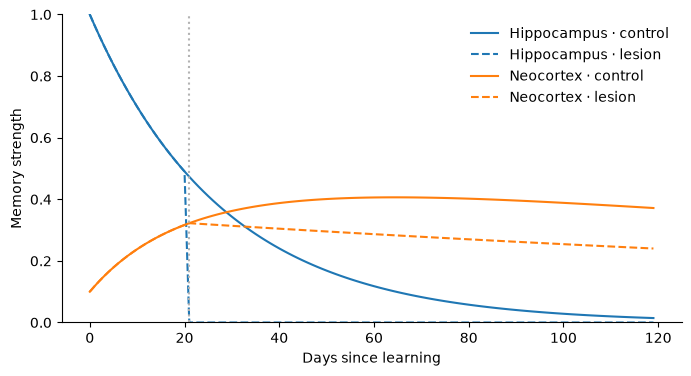

In [3]:
import matplotlib.pyplot as plt
p = PRESETS['monkey']
control = trajectory(p, 119)
lesion = trajectory(p, 119, lesion_day=21)
fig, ax = plt.subplots(figsize=(8, 4))
for index, name in enumerate(['Hippocampus', 'Neocortex']):
    line, = ax.plot(control[:, index], label=name + ' · control')
    ax.plot(lesion[:, index], '--', color=line.get_color(), label=name + ' · lesion')
ax.axvline(21, color='0.7', linestyle=':')
ax.set(xlabel='Days since learning', ylabel='Memory strength', ylim=(0, 1))
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.show()

## 4. From memory to performance

With $R_h=R_c=1$,
$$b_{hc}=S_h+(1-S_h)S_c,\qquad b_t=b_{hc}+(1-b_{hc})b_p.$$

$ b_p $ is the baseline response when neither memory succeeds. The same equations can therefore describe different task baselines. Free recall is shown as a proportion rather than a number of recalled items.

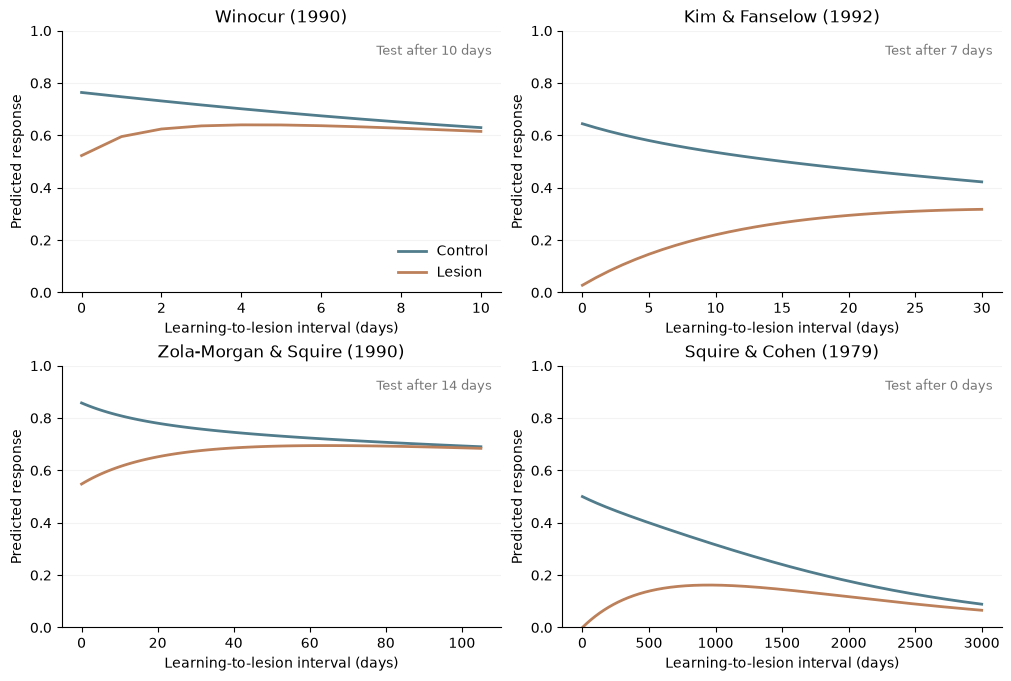

In [4]:
import numpy as np
STUDIES = {'winocur': {'name': 'Winocur (1990)', 'days': 10, 'recovery': 10, 'baseline': 0.5, 'default': 2}, 'kim': {'name': 'Kim & Fanselow (1992)', 'days': 30, 'recovery': 7, 'baseline': 0.0, 'default': 7}, 'monkey': {'name': 'Zola-Morgan & Squire (1990)', 'days': 105, 'recovery': 14, 'baseline': 0.5, 'default': 21}, 'squire': {'name': 'Squire & Cohen (1979)', 'days': 3000, 'recovery': 0, 'baseline': 0.0, 'default': 500}}

def plot_gradients():
    fig, axes = plt.subplots(2, 2, figsize=(10, 6.7), layout='constrained')
    for ax, (key, study) in zip(axes.flat, STUDIES.items()):
        delays = np.arange(study['days'] + 1)
        curves = lesion_gradient(PRESETS[key], delays, study['recovery'], study['baseline'])
        for condition, color in [('control', '#517c8b'), ('lesion', '#bc805a')]:
            ax.plot(delays, curves[condition].numpy(), label=condition.title(), color=color, lw=2)
        ax.set(title=study['name'], xlabel='Learning-to-lesion interval (days)',
               ylabel='Predicted response', ylim=(0, 1))
        ax.text(.98, .95, f"Test after {study['recovery']} days", transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color='#777777')
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', alpha=.15)
    axes[0, 0].legend(frameon=False, loc='lower right')
    return fig

plot_gradients();
plt.show()

## 5. What changes when consolidation stops?

Set $C=0$ to remove replay-driven learning while keeping hippocampal decay. Cortical memory can then only decrease. This isolates the role of consolidation.

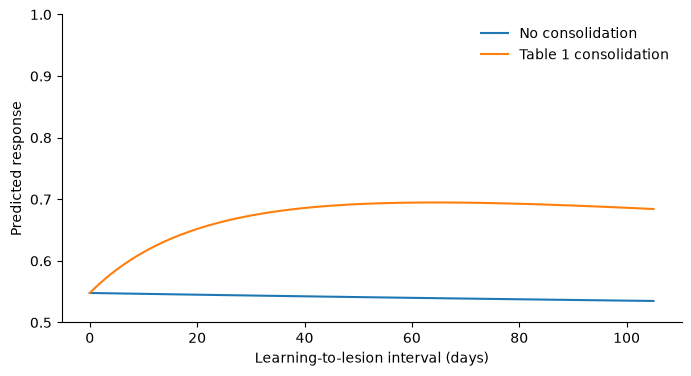

In [5]:
from dataclasses import replace
days = np.arange(106)
fig, ax = plt.subplots(figsize=(8, 4))
for rate, label in [(0., 'No consolidation'), (.02, 'Table 1 consolidation')]:
    p = replace(PRESETS['monkey'], C=rate)
    curve = lesion_gradient(p, days, recovery=14, baseline=.5)
    ax.plot(days, curve['lesion'], label=label)
ax.set(xlabel='Learning-to-lesion interval (days)', ylabel='Predicted response', ylim=(.5, 1))
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.show()

The curves reconstruct the published equations with explicit daily updates and test delays. They are not digitized animal data or an exact re-creation of the fitted lines in Figure 1. The paper reports rounded parameters and does not supply its fitting code; timing, response scaling, and numerical conventions are documented in TWO_SYSTEM_NOTES.md.